In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
#Loading the data.

df = pd.read_csv('../data/homicide_reports.csv')

print(f"Dataset loaded successfully\n")
print(f"Total rows: {len(df):,}")
print(f"\nTotal rows: {df.shape[0]}")
print(f"\nTotal columns: {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

Dataset loaded successfully

Total rows: 638,454

Total rows: 638454

Total columns: 24

Column names:
['Record ID', 'Agency Code', 'Agency Name', 'Agency Type', 'City', 'State', 'Year', 'Month', 'Incident', 'Crime Type', 'Crime Solved', 'Victim Sex', 'Victim Age', 'Victim Race', 'Victim Ethnicity', 'Perpetrator Sex', 'Perpetrator Age', 'Perpetrator Race', 'Perpetrator Ethnicity', 'Relationship', 'Weapon', 'Victim Count', 'Perpetrator Count', 'Record Source']


In [3]:
df.head()

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,...,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,...,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,...,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI


In [4]:
print("======== Data Types ========")
print(df.dtypes)

print("\n======== Missing Values ========\n")
print(df.isnull().sum())

print("\n ================== Solved vs Unsolved Cases=============\n")
print(df['Crime Solved'].value_counts())

======== Data Types ========
Record ID                 int64
Agency Code                 str
Agency Name                 str
Agency Type                 str
City                        str
State                       str
Year                      int64
Month                       str
Incident                  int64
Crime Type                  str
Crime Solved                str
Victim Sex                  str
Victim Age                int64
Victim Race                 str
Victim Ethnicity            str
Perpetrator Sex             str
Perpetrator Age          object
Perpetrator Race            str
Perpetrator Ethnicity       str
Relationship                str
Weapon                      str
Victim Count              int64
Perpetrator Count         int64
Record Source               str
dtype: object

======== Missing Values ========

Record ID                0
Agency Code              0
Agency Name              0
Agency Type              0
City                     0
State              

In [5]:
# Check how Unknown is encoded in key columns

cols_to_check = ['Victim Sex', 'Victim Race', 'Perpetrator Sex', 
                 'Perpetrator Race', 'Weapon', 'Relationship']

for col in cols_to_check:
    print(f"\n{col} unique values:")
    print(df[col].value_counts().head(8))


Victim Sex unique values:
Victim Sex
Male       494125
Female     143345
Unknown       984
Name: count, dtype: int64

Victim Race unique values:
Victim Race
White                            317422
Black                            299899
Asian/Pacific Islander             9890
Unknown                            6676
Native American/Alaska Native      4567
Name: count, dtype: int64

Perpetrator Sex unique values:
Perpetrator Sex
Male       399541
Unknown    190365
Female      48548
Name: count, dtype: int64

Perpetrator Race unique values:
Perpetrator Race
White                            218243
Black                            214516
Unknown                          196047
Asian/Pacific Islander             6046
Native American/Alaska Native      3602
Name: count, dtype: int64

Weapon unique values:
Weapon
Handgun          317484
Knife             94962
Blunt Object      67337
Firearm           46980
Unknown           33192
Shotgun           30722
Rifle             23347
Strangulation 

In [6]:
# Create target variable FIRST before dropping anything.
df['Target_Solved'] = df['Crime Solved'].map({'Yes': 1, 'No': 0})
print(df['Target_Solved'].head())

0    1
1    1
2    0
3    1
4    0
Name: Target_Solved, dtype: int64


In [7]:
#remove the data that might fool the model into learning patterns 
# that won't generalize to new cases.

leakage_cols = [
    'Perpetrator Age',
    'Perpetrator Sex', 
    'Perpetrator Race',
    'Perpetrator Ethnicity',
    'Perpetrator Count',
    'Crime Solved',  # replaced by Target_Solved
    'Record ID',     # just an ID, no predictive value
    'Agency Code',   # redundant with Agency Name
    'Record Source', # same source for everything
    'Incident'       # just a counter
]


df.drop(columns=leakage_cols, inplace=True)

print("✅ Leakage columns removed successfully\n")
print(f"Remaining columns : {list(df.columns)}")
print(f"\nShape after dropping leakage columns: {df.shape}")

✅ Leakage columns removed successfully

Remaining columns : ['Agency Name', 'Agency Type', 'City', 'State', 'Year', 'Month', 'Crime Type', 'Victim Sex', 'Victim Age', 'Victim Race', 'Victim Ethnicity', 'Relationship', 'Weapon', 'Victim Count', 'Target_Solved']

Shape after dropping leakage columns: (638454, 15)


In [8]:
#replace 'Unknown' values.

unknown_values = ['Unknown', 'unknown', 'UNKNOWN']

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace(unknown_values, np.nan)


# Perpetrator Age = 0 means Unknown in FBI data.
#print(df[df['Victim Age'] == 0].value_counts())
# Replace Victim Age = 0 with NaN since it means Unknown.
df['Victim Age'] = df['Victim Age'].replace(0, np.nan)


print("Victim Age after fixing zeros:")
print(df['Victim Age'].value_counts().head(10))
print(df['Victim Age'].value_counts().tail(10))
print(f"\nUnknown ages (NaN count): {df['Victim Age'].isna().sum():,}")




Victim Age after fixing zeros:
Victim Age
22.0    23049
20.0    23031
25.0    22939
21.0    22796
23.0    22438
19.0    21939
24.0    21830
26.0    20469
27.0    19465
30.0    18966
Name: count, dtype: int64
Victim Age
89.0    313
90.0    281
91.0    215
92.0    156
93.0    134
94.0    116
95.0     82
97.0     39
96.0     37
98.0     33
Name: count, dtype: int64

Unknown ages (NaN count): 8,444


In [9]:
#=============Handle Missing Values================

# Fill Victim Age nulls with median age
median_age = df['Victim Age'].median()
df['Victim Age'] = df['Victim Age'].fillna(median_age)

# Fill categorical nulls with 'Unknown'
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')


print(f"✅ Missing values handled")
print(f"📊 Median age used for fill: {median_age}")
print(f"\nRemaining nulls:")
print(df.isnull().sum())
print(f"\nDataset shape: {df.shape}")

✅ Missing values handled
📊 Median age used for fill: 30.0

Remaining nulls:
Agency Name         0
Agency Type         0
City                0
State               0
Year                0
Month               0
Crime Type          0
Victim Sex          0
Victim Age          0
Victim Race         0
Victim Ethnicity    0
Relationship        0
Weapon              0
Victim Count        0
Target_Solved       0
dtype: int64

Dataset shape: (638454, 15)


In [10]:
#=========================Feature Engineering========================

In [11]:
# Decade Feature

# Map years into decades
def get_decade(year):
    if year < 1990:
        return '1980s'
    elif year < 2000:
        return '1990s'
    elif year < 2010:
        return '2000s'
    else:
        return '2010s'

df['Decade'] = df['Year'].apply(get_decade)

print("✅ Decade column created")
print(df['Decade'].value_counts())

✅ Decade column created
Decade
1990s    203901
1980s    198531
2000s    162336
2010s     73686
Name: count, dtype: int64


In [12]:
# Victim Age Group

# Bin continuous age into meaningful life stages
def get_age_group(age):
    if age <= 12:
        return 'Child'
    elif age <= 17:
        return 'Teen'
    elif age <= 30:
        return 'Young Adult'
    elif age <= 59:
        return 'Adult'
    else:
        return 'Senior'

df['Victim Age Group'] = df['Victim Age'].apply(get_age_group)

print("✅ Victim Age Group created")
print(df['Victim Age Group'].value_counts())

✅ Victim Age Group created
Victim Age Group
Young Adult    280071
Adult          247553
Senior          55089
Teen            34576
Child           21165
Name: count, dtype: int64


In [13]:
#Weapon Grouping

# Check all weapon types first
print("All weapon types:")
print(df['Weapon'].value_counts())




All weapon types:
Weapon
Handgun          317484
Knife             94962
Blunt Object      67337
Firearm           46980
Unknown           33192
Shotgun           30722
Rifle             23347
Strangulation      8110
Fire               6173
Suffocation        3968
Gun                2206
Drugs              1588
Drowning           1204
Explosives          537
Poison              454
Fall                190
Name: count, dtype: int64


In [14]:
# Group weapons into clean categories
weapon_map = {
    'Handgun'       : 'Firearm',
    'Firearm'       : 'Firearm',
    'Shotgun'       : 'Firearm',
    'Rifle'         : 'Firearm',
    'Gun'           : 'Firearm',
    'Knife'         : 'Knife',
    'Blunt Object'  : 'Blunt Object',
    'Strangulation' : 'Personal Violence',
    'Suffocation'   : 'Personal Violence',
    'Drowning'      : 'Personal Violence',
    'Fire'          : 'Other',
    'Drugs'         : 'Other',
    'Explosives'    : 'Other',
    'Poison'        : 'Other',
    'Fall'          : 'Other',
    'Unknown'       : 'Unknown'
}

df['Weapon Grouped'] = df['Weapon'].map(weapon_map)

print("✅ Weapon Grouped column created")
print(df['Weapon Grouped'].value_counts())

✅ Weapon Grouped column created
Weapon Grouped
Firearm              420739
Knife                 94962
Blunt Object          67337
Unknown               33192
Personal Violence     13282
Other                  8942
Name: count, dtype: int64


In [15]:
#Agency Type Grouping.

# Check agency types.
print("Agency types:")
print(df['Agency Type'].value_counts())

Agency types:
Agency Type
Municipal Police    493026
Sheriff             105322
County Police        22693
State Police         14235
Special Police        2889
Regional Police        235
Tribal Police           54
Name: count, dtype: int64


In [16]:
agency_map = {
    'Municipal Police' : 'Municipal',
    'Sheriff'          : 'Sheriff',
    'County Police'    : 'County',
    'State Police'     : 'State',
    'Special Police'   : 'Special',
    'Regional Police'  : 'Regional',
    'Tribal Police'    : 'Tribal'
}

df['Agency Grouped'] = df['Agency Type'].map(agency_map)

print("✅ Agency Grouped column created")
print(df['Agency Grouped'].value_counts())

✅ Agency Grouped column created
Agency Grouped
Municipal    493026
Sheriff      105322
County        22693
State         14235
Special        2889
Regional        235
Tribal           54
Name: count, dtype: int64


In [17]:
print(df['Relationship'].value_counts())

Relationship
Unknown                 273013
Acquaintance            126018
Stranger                 96593
Wife                     23187
Friend                   21945
Girlfriend               16465
Son                       9904
Family                    9535
Husband                   8803
Daughter                  7539
Boyfriend                 7302
Neighbor                  6294
Brother                   5514
Father                    4361
Mother                    4248
In-Law                    3637
Common-Law Wife           2477
Ex-Wife                   1973
Common-Law Husband        1954
Boyfriend/Girlfriend      1383
Stepfather                1360
Sister                    1292
Stepson                   1170
Stepdaughter               754
Ex-Husband                 629
Employer                   509
Employee                   384
Stepmother                 211
Name: count, dtype: int64


In [18]:
relationship_map = {
    # Intimate Partners
    'Wife'                  : 'Intimate Partner',
    'Husband'               : 'Intimate Partner',
    'Girlfriend'            : 'Intimate Partner',
    'Boyfriend'             : 'Intimate Partner',
    'Common-Law Wife'       : 'Intimate Partner',
    'Common-Law Husband'    : 'Intimate Partner',
    'Ex-Wife'               : 'Intimate Partner',
    'Ex-Husband'            : 'Intimate Partner',
    'Boyfriend/Girlfriend'  : 'Intimate Partner',

    # Family
    'Son'                   : 'Family',
    'Daughter'              : 'Family',
    'Brother'               : 'Family',
    'Sister'                : 'Family',
    'Father'                : 'Family',
    'Mother'                : 'Family',
    'Stepfather'            : 'Family',
    'Stepmother'            : 'Family',
    'Stepson'               : 'Family',
    'Stepdaughter'          : 'Family',
    'In-Law'                : 'Family',
    'Family'                : 'Family',

    # Social Circle
    'Acquaintance'          : 'Known',
    'Friend'                : 'Known',
    'Neighbor'              : 'Known',

    # Work
    'Employer'              : 'Work Related',
    'Employee'              : 'Work Related',

    # No Connection
    'Stranger'              : 'Stranger',
    'Unknown'               : 'Unknown'
}

df['Relationship Grouped'] = df['Relationship'].map(relationship_map)

print("✅ Relationship Grouped created")
print(df['Relationship Grouped'].value_counts())

✅ Relationship Grouped created
Relationship Grouped
Unknown             273013
Known               154257
Stranger             96593
Intimate Partner     64173
Family               49525
Work Related           893
Name: count, dtype: int64


In [19]:

# Drop redundant source columns
columns_to_drop = [
    'Year',          # replaced by Decade
    'Victim Age',    # replaced by Victim Age Group
    'Weapon',        # replaced by Weapon Grouped
    'Relationship',  # replaced by Relationship Grouped
    'Agency Type',   # replaced by Agency Grouped
    'Agency Name',   # too many unique values
    'City',          # State covers geography
    'Crime Type',    # only one value in this dataset
    'Victim Ethnicity' # too many unknowns, low signal
]

df_final = df.drop(columns=columns_to_drop)


In [20]:
df_final.to_csv('../data/homicide_cleaned.csv', index=False)

print(f"✅ Clean dataset saved with Relationship Grouping!")
print(f"📊 Final shape: {df_final.shape}")
print(f"📋 Final columns: {list(df_final.columns)}")


✅ Clean dataset saved with Relationship Grouping!
📊 Final shape: (638454, 11)
📋 Final columns: ['State', 'Month', 'Victim Sex', 'Victim Race', 'Victim Count', 'Target_Solved', 'Decade', 'Victim Age Group', 'Weapon Grouped', 'Agency Grouped', 'Relationship Grouped']


In [21]:
df = pd.read_csv('../data/homicide_cleaned.csv')
print(f"✅ Dataset loaded: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")

print(f"\nTarget distribution:")
print(df['Target_Solved'].value_counts())
print(f"\nSolve rate: {df['Target_Solved'].mean()*100:.1f}%")

✅ Dataset loaded: (638454, 11)
📋 Columns: ['State', 'Month', 'Victim Sex', 'Victim Race', 'Victim Count', 'Target_Solved', 'Decade', 'Victim Age Group', 'Weapon Grouped', 'Agency Grouped', 'Relationship Grouped']

Target distribution:
Target_Solved
1    448172
0    190282
Name: count, dtype: int64

Solve rate: 70.2%


## K-Modes Clustering

In [22]:
from kmodes.kmodes import KModes
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

print("✅ KModes imported successfully")

✅ KModes imported successfully


In [23]:
# Filter to unsolved cases only
df_unsolved = df[df['Target_Solved'] == 0].copy()

# Drop target variable — not needed for clustering
df_unsolved = df_unsolved.drop(columns=['Target_Solved', 'Month', 'Victim Count'])

print(f"✅ Unsolved cases: {len(df_unsolved):,}")
print(f"📋 Clustering features: {list(df_unsolved.columns)}")
print(df_unsolved.shape)

✅ Unsolved cases: 190,282
📋 Clustering features: ['State', 'Victim Sex', 'Victim Race', 'Decade', 'Victim Age Group', 'Weapon Grouped', 'Agency Grouped', 'Relationship Grouped']
(190282, 8)


Running Elbow Method — this takes 3-5 minutes...


  K=2 done — Cost: 501,525
  K=3 done — Cost: 471,666
  K=4 done — Cost: 454,174
  K=5 done — Cost: 436,541
  K=6 done — Cost: 409,564
  K=7 done — Cost: 407,408
  K=8 done — Cost: 402,711


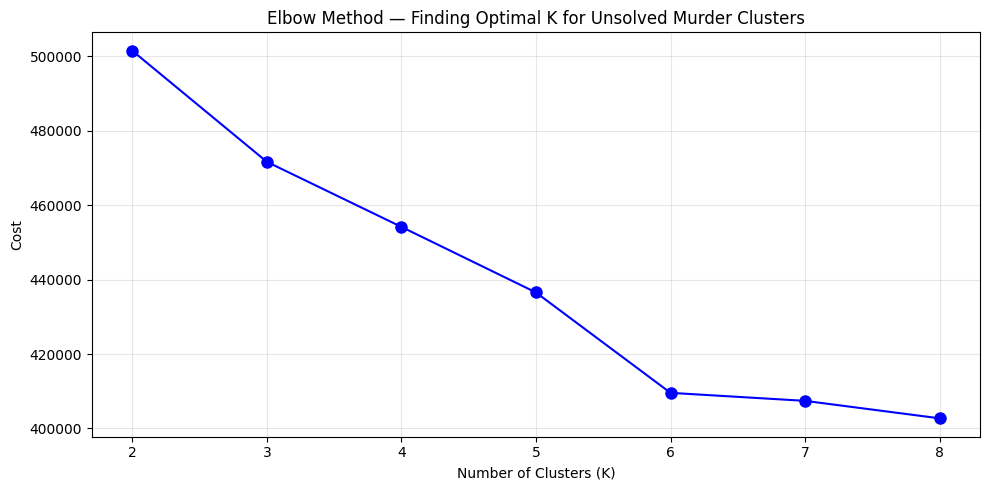

✅ Elbow curve saved!


In [24]:
# Test K from 2 to 8 and plot cost
costs = []
K_range = range(2, 9)

print("Running Elbow Method — this takes 3-5 minutes...")

for k in K_range:
    km = KModes(n_clusters=k, init='Huang', n_init=3, verbose=0)
    km.fit(df_unsolved)
    costs.append(km.cost_)
    print(f"  K={k} done — Cost: {km.cost_:,.0f}")

# Plot elbow curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, costs, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cost')
plt.title('Elbow Method — Finding Optimal K for Unsolved Murder Clusters')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/elbow_curve.png', dpi=150)
plt.show()

print("✅ Elbow curve saved!")

In [25]:
print("Training K-Modes with K=5...")

km_final = KModes(n_clusters=5, init='Huang', n_init=5, verbose=0)
clusters = km_final.fit_predict(df_unsolved)

# Add cluster labels back to unsolved dataframe
df_unsolved['Cluster_ID'] = clusters

print(f"✅ Clustering complete!")
print(f"\nCluster distribution:")
print(df_unsolved['Cluster_ID'].value_counts().sort_index())

Training K-Modes with K=5...
✅ Clustering complete!

Cluster distribution:
Cluster_ID
0    52356
1    43832
2    59180
3    24825
4    10089
Name: count, dtype: int64


In [26]:
# Get the centroid of each cluster — this is the "profile"
centroids = pd.DataFrame(
    km_final.cluster_centroids_,
    columns=df_unsolved.columns[:-1]  # exclude Cluster_ID
)

centroids.index.name = 'Cluster_ID'
print("🔪 Most Dangerous Profiles — Cluster Centroids:")
print(centroids.to_string())

🔪 Most Dangerous Profiles — Cluster Centroids:
                 State Victim Sex Victim Race Decade Victim Age Group Weapon Grouped Agency Grouped Relationship Grouped
Cluster_ID                                                                                                              
0           California       Male       White  2000s            Adult        Firearm      Municipal              Unknown
1             New York       Male       Black  1980s            Adult        Firearm      Municipal              Unknown
2           California       Male       Black  1990s      Young Adult        Firearm      Municipal              Unknown
3           California       Male       White  1980s            Adult        Firearm      Municipal              Unknown
4           California     Female       Black  1990s            Adult        Firearm      Municipal              Unknown


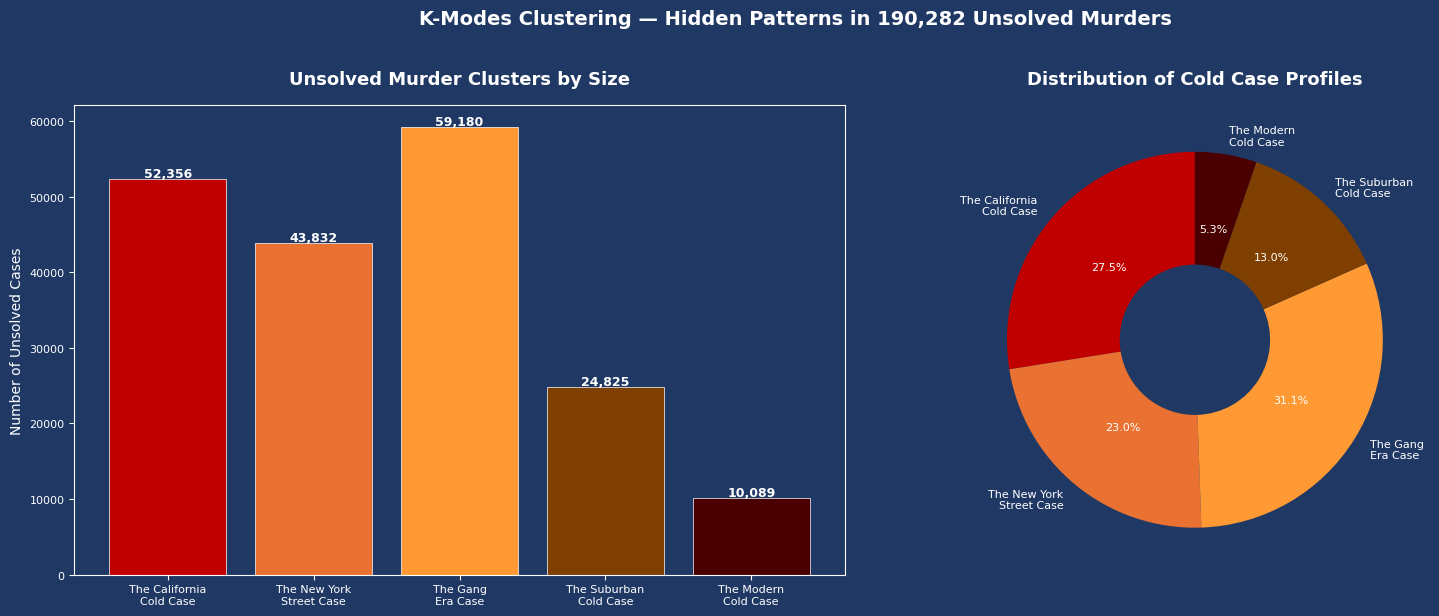

✅ Cluster visualization saved!


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Cluster sizes and nicknames
cluster_names = {
    0: 'The California\nCold Case',
    1: 'The New York\nStreet Case',
    2: 'The Gang\nEra Case',
    3: 'The Suburban\nCold Case',
    4: 'The Modern\nCold Case'
}

cluster_sizes = df_unsolved['Cluster_ID'].value_counts().sort_index()
colors = ['#C00000', '#E97132', '#FF9933', '#7F3F00', '#4A0000']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1F3864')

# Plot 1 — Cluster sizes bar chart
axes[0].bar(
    [cluster_names[i] for i in range(5)],
    cluster_sizes.values,
    color=colors,
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_facecolor('#1F3864')
axes[0].set_title('Unsolved Murder Clusters by Size',
                   color='white', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Unsolved Cases', color='white')
axes[0].tick_params(colors='white', labelsize=8)
for spine in axes[0].spines.values():
    spine.set_edgecolor('white')

# Add value labels on bars
for i, v in enumerate(cluster_sizes.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center',
                color='white', fontsize=9, fontweight='bold')

# Plot 2 — Donut chart
wedges, texts, autotexts = axes[1].pie(
    cluster_sizes.values,
    labels=[cluster_names[i] for i in range(5)],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
for text in texts:
    text.set_color('white')
    text.set_fontsize(8)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(8)

axes[1].set_facecolor('#1F3864')
axes[1].set_title('Distribution of Cold Case Profiles',
                   color='white', fontsize=13, fontweight='bold', pad=15)

plt.suptitle('K-Modes Clustering — Hidden Patterns in 190,282 Unsolved Murders',
             color='white', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../outputs/cluster_profiles.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1F3864')
plt.show()
print("✅ Cluster visualization saved!")

In [30]:
# Commit message for git later
print("Phase 3 Complete — Summary:")
print(f"Total unsolved cases clustered: 190,282")
print(f"Optimal K: 5")
print(f"\n5 Cold Case Profiles Found:")
print(f"  Cluster 0 — The California Cold Case: 52,356 cases")
print(f"  Cluster 1 — The New York Street Case: 43,832 cases")
print(f"  Cluster 2 — The Gang Era Case: 59,180 cases (LARGEST)")
print(f"  Cluster 3 — The Suburban Cold Case: 24,825 cases")
print(f"  Cluster 4 — The Modern Cold Case: 10,089 cases")


Phase 3 Complete — Summary:
Total unsolved cases clustered: 190,282
Optimal K: 5

5 Cold Case Profiles Found:
  Cluster 0 — The California Cold Case: 52,356 cases
  Cluster 1 — The New York Street Case: 43,832 cases
  Cluster 2 — The Gang Era Case: 59,180 cases (LARGEST)
  Cluster 3 — The Suburban Cold Case: 24,825 cases
  Cluster 4 — The Modern Cold Case: 10,089 cases


In [4]:
# Add cluster IDs back to full dataset
# First create a mapping
df['Cluster_ID'] = -1  # default for solved cases

# Assign cluster IDs to unsolved cases
df.loc[df['Target_Solved'] == 0, 'Cluster_ID'] = clusters

# Save
df.to_csv('../data/homicide_clustered.csv', index=False)

print(f"✅ Clustered dataset saved!")
print(f"📊 Shape: {df.shape}")
print(f"\nCluster distribution in full dataset:")
print(df['Cluster_ID'].value_counts().sort_index())

NameError: name 'df' is not defined

In [5]:
print(f"✅ Total rows: {len(df):,}")
print(f"✅ Solved cases: {(df['Target_Solved']==1).sum():,}")
print(f"✅ Unsolved cases: {(df['Target_Solved']==0).sum():,}")
print(f"✅ Clustered unsolved: {(df['Cluster_ID']>=0).sum():,}")
print(f"✅ Columns: {list(df.columns)}")

NameError: name 'df' is not defined

# ==============================================================================
# Phase 4 — Random Forest + SMOTE (Corrected for One-Hot Encoding)
# ==============================================================================


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import joblib
import pandas as pd

print("✅ All Phase 4 libraries imported!")

df = pd.read_csv('../data/homicide_clustered.csv')
print(f"✅ Data loaded successfully! Shape: {df.shape}")

✅ All Phase 4 libraries imported!
✅ Data loaded successfully! Shape: (638454, 12)


In [10]:
df_model = df.copy()
df_model = df_model.drop(columns=['Cluster_ID'])

X_raw = df_model.drop(columns=['Target_Solved'])
y = df_model['Target_Solved']

print("Applying One-Hot Encoding to categorical variables...")
# get_dummies converts nominal categories into separate binary (1/0) columns
# drop_first=True prevents perfect multicollinearity
X = pd.get_dummies(X_raw, drop_first=True)

print(f"✅ Encoding complete! Expanded feature count: {X.shape[1]}")

print("✅ Categorical columns encoded!")
print(f"\nDataset preview:")
print(X.head(3))

Applying One-Hot Encoding to categorical variables...
✅ Encoding complete! Expanded feature count: 91
✅ Categorical columns encoded!

Dataset preview:
   Victim Count  State_Alaska  State_Arizona  State_Arkansas  \
0             0          True          False           False   
1             0          True          False           False   
2             0          True          False           False   

   State_California  State_Colorado  State_Connecticut  State_Delaware  \
0             False           False              False           False   
1             False           False              False           False   
2             False           False              False           False   

   State_District of Columbia  State_Florida  ...  Agency Grouped_Regional  \
0                       False          False  ...                    False   
1                       False          False  ...                    False   
2                       False          False  ...            

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Data split complete!")
print(f"Training target distribution:\n{y_train.value_counts()}")


✅ Data split complete!
Training target distribution:
Target_Solved
1    358537
0    152226
Name: count, dtype: int64


In [12]:
print("Applying SMOTE to balance classes...")
print(f"Before SMOTE — Solved: {(y_train==1).sum():,} | Unsolved: {(y_train==0).sum():,}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  — Solved: {(y_train_smote==1).sum():,} | Unsolved: {(y_train_smote==0).sum():,}")
print(f"✅ Classes perfectly balanced!")

Applying SMOTE to balance classes...
Before SMOTE — Solved: 358,537 | Unsolved: 152,226
After SMOTE  — Solved: 358,537 | Unsolved: 358,537
✅ Classes perfectly balanced!


In [13]:
# Train Random Forest

print("\nTraining Random Forest — this takes 3-5 minutes...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train_smote, y_train_smote)
print("✅ Random Forest trained!")


Training Random Forest — this takes 3-5 minutes...
✅ Random Forest trained!


In [14]:
#Evaluate Model

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy*100:.1f}%")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Unsolved', 'Solved']))

cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=['Actual Unsolved', 'Actual Solved'],
    columns=['Predicted Unsolved', 'Predicted Solved']
)
print("\n📊 Confusion Matrix:")
print(cm)

✅ Model Accuracy: 83.4%

📊 Classification Report:
              precision    recall  f1-score   support

    Unsolved       0.66      0.93      0.77     38056
      Solved       0.96      0.79      0.87     89635

    accuracy                           0.83    127691
   macro avg       0.81      0.86      0.82    127691
weighted avg       0.87      0.83      0.84    127691


📊 Confusion Matrix:
                 Predicted Unsolved  Predicted Solved
Actual Unsolved               35441              2615
Actual Solved                 18541             71094


📊 Feature Importance Rankings:
                                  Feature  Importance
89           Relationship Grouped_Unknown    0.573557
87             Relationship Grouped_Known    0.173417
86  Relationship Grouped_Intimate Partner    0.068183
88          Relationship Grouped_Stranger    0.063440
71                 Victim Age Group_Child    0.013801
..                                    ...         ...
29                    State_New Hampshire    0.000009
39                    State_Rhodes Island    0.000008
50                          State_Wyoming    0.000008
81                Agency Grouped_Regional    0.000007
85                  Agency Grouped_Tribal    0.000005

[91 rows x 2 columns]


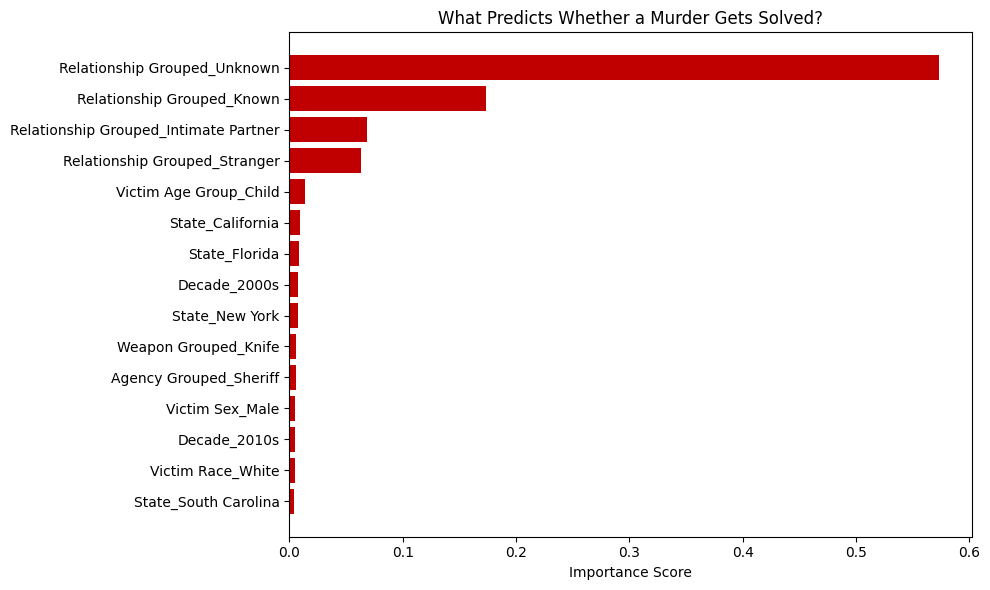

✅ Feature importance chart saved!


In [20]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("📊 Feature Importance Rankings:")
print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance['Feature'].head(15),
    feature_importance['Importance'].head(15),
    color='#C00000'
)
plt.xlabel('Importance Score')
plt.title('What Predicts Whether a Murder Gets Solved?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance chart saved!")

In [23]:
#Cold Case Risk Score & Save

X_test_results = X_test.copy()
X_test_results['Target_Solved'] = y_test.values
X_test_results['Predicted_Solved'] = y_pred
X_test_results['Solve_Probability'] = y_pred_proba
X_test_results['Cold_Case_Risk_Score'] = (1 - y_pred_proba) * 100

print("\n✅ Cold Case Risk Score created!")
print(f"Target Solved: {X_test_results['Target_Solved'].sum()}")
print(f"Predicted Solved: {X_test_results['Predicted_Solved'].sum()}")
print(f"Target Not Solved: {len(X_test_results) - X_test_results['Target_Solved'].sum()}")
print(f"Predicted Not Solved: {len(X_test_results) - X_test_results['Predicted_Solved'].sum()}")

print(f"\nPredicted Probability Distribution:")
print(X_test_results['Solve_Probability'].describe())

print(f"\nRisk Score distribution:")
print(X_test_results['Cold_Case_Risk_Score'].describe())

# Save model
joblib.dump(rf_model, '../models/cold_case_rf_model.pkl')
print(f"\n✅ Model saved!")

# Save results
X_test_results.to_csv('../data/rf_results.csv', index=False)
print(f"✅ Results saved to rf_results.csv!")


✅ Cold Case Risk Score created!
Target Solved: 89635
Predicted Solved: 73709
Target Not Solved: 38056
Predicted Not Solved: 53982

Predicted Probability Distribution:
count    127691.000000
mean          0.609991
std           0.347035
min           0.070631
25%           0.203670
50%           0.814760
75%           0.943133
max           0.996523
Name: Solve_Probability, dtype: float64

Risk Score distribution:
count    127691.000000
mean         39.000928
std          34.703496
min           0.347666
25%           5.686742
50%          18.523989
75%          79.633001
max          92.936931
Name: Cold_Case_Risk_Score, dtype: float64

✅ Model saved!
✅ Results saved to rf_results.csv!
